In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, ConcatDataset, Subset
from torchvision import datasets, transforms, models
import matplotlib.pyplot as plt
import os
import random
import numpy as np
from sklearn.model_selection import StratifiedKFold

os.environ["CUDA_VISIBLE_DEVICES"] = "0"

In [2]:
# Seed 고정 
def set_seed(seed=42):
    random.seed(seed) # python 기본 random 라이브러리 seed 고정 
    np.random.seed(seed) # Numpy random seed 고정 
    torch.manual_seed(seed) # Pytorch CPU 연산 seed 고정 
    torch.cuda.manual_seed_all(seed) # Pytorch GPU 연산 seed 고정 (GPU 여러 개도 전부 고정)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False 

set_seed(42)

In [3]:
# GPU 사용 가능 여부 확인
print(f"GPU 사용 가능 여부: {torch.cuda.is_available()}")

# 사용 가능한 GPU 개수 및 이름 확인
if torch.cuda.is_available():
    print(f"GPU 개수: {torch.cuda.device_count()}")
    print(f"현재 GPU 이름: {torch.cuda.get_device_name(0)}")

GPU 사용 가능 여부: True
GPU 개수: 1
현재 GPU 이름: NVIDIA TITAN Xp


In [4]:
# 하이퍼파라미터 설정
BATCH_SIZE=32
EPOCHS= 10
LR =0.001
NUM_CLASSES =2
N_SPLITS    = 10 # 10-fold CV
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [5]:
import glob 
import os 

# 경로 지정 
root='./'
image_folder_path = os.path.join(root, 'product_images') 

# images 폴더가 없으면 생성(이미 존재하면 건너뜀)
if not os.path.exists(image_folder_path):
    os.makedirs(image_folder_path)

import kaggle
kaggle.api.dataset_download_files('ravirajsinh45/real-life-industrial-dataset-of-casting-product', path=image_folder_path, unzip=True)

print(image_folder_path)
print(glob.glob(image_folder_path+'/*')) 

Dataset URL: https://www.kaggle.com/datasets/ravirajsinh45/real-life-industrial-dataset-of-casting-product
./product_images
['./product_images/casting_data', './product_images/casting_512x512']


In [6]:
TRAIN_DIR = os.path.join(image_folder_path, "casting_data", "casting_data","train")
TEST_DIR = os.path.join(image_folder_path, "casting_data", "casting_data", "test")

print("Train 경로:", TRAIN_DIR)
print("TEST 경로:", TEST_DIR)

Train 경로: ./product_images/casting_data/casting_data/train
TEST 경로: ./product_images/casting_data/casting_data/test


In [7]:
# Gaussian Noise 클래스 (이미지에 랜덤한 잡음을 추가하는 부분)
class AddGaussianNoise(object):
    def __init__(self, mean=0., std=0.01):
        self.mean = mean # 노이즈 평균 (0 = 중심)
        self.std = std # 노이즈 강도(클수록 노이즈 강함)

    # transform.Compose에서 호출될 때 실행되는 함수(__call__ 덕분)     
    def __call__(self, tensor):
        # torch.randn_like(tensor) -> tensor와 같은 크기의 랜덤 노이즈 생성 
        # * self.std, self.mean -> 노이즈 조절 
        # tensor + 노이즈 -> 원본 이미지에 노이즈 추가
        noisy = tensor + torch.randn_like(tensor) * self.std + self.mean

        # clamp → 픽셀값을 0~1 사이로 제한
        # 노이즈 추가 후 픽셀값이 0 이만이거나 1 초과가 될 수 있어서
        return torch.clamp(noisy, 0.0, 1.0)

In [8]:
# VGGNet 19-layer (VGG-19) 정의 
class MVGG19(nn.Module):
    def __init__(self, num_classes=2):
        super(MVGG19, self).__init__()

        # pretrained VGG19 불러오기(torchvision에서 제공)
        backbone = models.vgg19(weights=models.VGG19_Weights.IMAGENET1K_V1)
        features = backbone.features
        print(backbone.features)

        # 블록별 분리
        self.block1 = features[0:5]    # 64ch
        self.block2 = features[5:10]   # 128ch
        self.block3 = features[10:19]  # 256ch
        self.block4 = features[19:28]  # 512ch
        self.block5 = features[28:37]  # 512ch

        # backbone freeze (논문 명시: 마지막 층만 학습, 나머지 freeze)
        for block in [self.block1, self.block2, self.block3,
                      self.block4, self.block5]:
            for param in block.parameters():
                param.requires_grad = False

        # # Block 1 : 2 conv + maxpool
        # self.block1 = nn.Sequential(
        #     nn.Conv2d(3, 64, kernel_size=3, padding=1),
        #     nn.BatchNorm2d(64),
        #     nn.ReLU(inplace=True),
        #     nn.Conv2d(64, 64, kernel_size=3, padding=1),
        #     nn.BatchNorm2d(64),
        #     nn.ReLU(inplace=True),
        #     nn.MaxPool2d(kernel_size=2, stride=2),
        # )

        # # Block 2 : 2 conv + maxpool
        # self.block2 = nn.Sequential(
        #     nn.Conv2d(64, 128, kernel_size=3, padding=1),
        #     nn.BatchNorm2d(128),
        #     nn.ReLU(inplace=True),
        #     nn.Conv2d(128, 128, kernel_size=3, padding=1),
        #     nn.BatchNorm2d(128),
        #     nn.ReLU(inplace=True),
        #     nn.MaxPool2d(kernel_size=2, stride=2),
        # )

        # # Block 3 : 4 conv + maxpool
        # self.block3 = nn.Sequential(
        #     nn.Conv2d(128, 256, kernel_size=3, padding=1),
        #     nn.BatchNorm2d(256),
        #     nn.ReLU(inplace=True),
        #     nn.Conv2d(256, 256, kernel_size=3, padding=1),
        #     nn.BatchNorm2d(256),
        #     nn.ReLU(inplace=True),
        #     nn.Conv2d(256, 256, kernel_size=3, padding=1),
        #     nn.BatchNorm2d(256),
        #     nn.ReLU(inplace=True),
        #     nn.Conv2d(256, 256, kernel_size=3, padding=1),
        #     nn.BatchNorm2d(256),
        #     nn.ReLU(inplace=True),
        #     nn.MaxPool2d(kernel_size=2, stride=2),
        # )

        # # Block 4 : 4 conv + maxpool
        # self.block4 = nn.Sequential(
        #     nn.Conv2d(256, 512, kernel_size=3, padding=1),
        #     nn.BatchNorm2d(512),
        #     nn.ReLU(inplace=True),
        #     nn.Conv2d(512, 512, kernel_size=3, padding=1),
        #     nn.BatchNorm2d(512),
        #     nn.ReLU(inplace=True),
        #     nn.Conv2d(512, 512, kernel_size=3, padding=1),
        #     nn.BatchNorm2d(512),
        #     nn.ReLU(inplace=True),
        #     nn.Conv2d(512, 512, kernel_size=3, padding=1),
        #     nn.BatchNorm2d(512),
        #     nn.ReLU(inplace=True),
        #     nn.MaxPool2d(kernel_size=2, stride=2),
        # )

        # # Block 5 : 4 conv + maxpool
        # self.block5 = nn.Sequential(
        #     nn.Conv2d(512, 512, kernel_size=3, padding=1),
        #     nn.BatchNorm2d(512),
        #     nn.ReLU(inplace=True),
        #     nn.Conv2d(512, 512, kernel_size=3, padding=1),
        #     nn.BatchNorm2d(512),
        #     nn.ReLU(inplace=True),
        #     nn.Conv2d(512, 512, kernel_size=3, padding=1),
        #     nn.BatchNorm2d(512),
        #     nn.ReLU(inplace=True),
        #     nn.Conv2d(512, 512, kernel_size=3, padding=1),
        #     nn.BatchNorm2d(512),
        #     nn.ReLU(inplace=True),
        #     nn.MaxPool2d(kernel_size=2, stride=2),
        # )

        # BD 브랜치 (Block 3 이후)
        # Batch Normalization + Dropout + Global Average Pooling
        # Block3 이후 feature를 bd1으로 따로 보존하기
        self.bd1 = nn.Sequential(
            nn.BatchNorm2d(256),
            nn.Dropout(0.5),
            nn.AdaptiveAvgPool2d((1, 1))  # Global Average Pooling → 1x1(어떤 크기든 1x1로 줄인다)
        )

        # BD 브랜치 (Block 4 이후)
        # Block4 이후 feature를 bd2로 따로 보존하기
        self.bd2 = nn.Sequential(
            nn.BatchNorm2d(512),
            nn.Dropout(0.5),
            nn.AdaptiveAvgPool2d((1, 1))  # Global Average Pooling → 1x1
        )

        # BD 브랜치 (Block 5 이후)
        # Block5 이후 feature를 bd3로 따로 보존하기
        self.bd3 = nn.Sequential(
            nn.BatchNorm2d(512),
            nn.Dropout(0.5),
            nn.AdaptiveAvgPool2d((1, 1))  # Global Average Pooling → 1x1
        )

        # 메인 경로 GAP
        # 마지막 feature -> GAP으로 보존 
        self.gap = nn.AdaptiveAvgPool2d((1, 1))

        # Concatenation 이후 Dense 층
        # bd1(256) + bd2(512) + bd3(512) + main(512) = 1792
        # Convolution + ReLU layers (3x3 convolution, padding=1)
        # nn.Sequential는 "레이어를 순서대로 담는 상자"이다.
        self.classifier = nn.Sequential(
            nn.Linear(256 + 512 + 512 + 512, 2500),
            nn.BatchNorm1d(2500),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(2500, num_classes)
        )


    def forward(self,x):
        # 순차적으로 block 통과 
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)

        # BD 브랜치 1 (Block3 이후)
        bd1_out = self.bd1(x) # (batch, 256, 37, 37) -> (batch, 256, 1, 1)
        bd1_out = bd1_out.view(bd1_out.size(0), -1)  # Flatten (batch, 256, 1, 1) → (batch, 256)

        x = self.block4(x) # (batch, 256, 37, 37) -> (batch, 512, 18, 18)

        # BD 브랜치 2 (Block4 이후)
        bd2_out = self.bd2(x) # (batch, 512, 18, 18) -> (batch, 512, 1, 1)
        bd2_out = bd2_out.view(bd2_out.size(0), -1)  # Flatten → (batch, 512)

        x = self.block5(x) # (batch, 512, 9, 9)
        
        # BD 브랜치 3 (Block5 이후)
        bd3_out = self.bd3(x) # (batch, 512, 9, 9) -> (batch, 512, 1, 1)
        bd3_out = bd3_out.view(bd3_out.size(0), -1)  # Flatten → (batch, 512)

        # 메인 경로 GAP
        main_out = self.gap(x) # (batch, 512, 9, 9) -> (batch, 512, 1, 1)
        main_out = main_out.view(main_out.size(0), -1)  # Flatten → (batch, 512)

        # Concatenation (bd1 + bd2 + bd3 + main)
        # (batch, 256) + (batch, 512) + (batch, 512) + (batch, 512) -> (batch, 1792)
        out = torch.cat([bd1_out, bd2_out, bd3_out, main_out], dim=1)  

        # Dense → 분류
        out = self.classifier(out) # (batch, 1792) -> (batch, 2)
        return out
    
model = MVGG19(num_classes=2).to(DEVICE)
print(f"Using device : {DEVICE}")
# print(model)

Sequential(
  (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ReLU(inplace=True)
  (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (3): ReLU(inplace=True)
  (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (6): ReLU(inplace=True)
  (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (8): ReLU(inplace=True)
  (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (11): ReLU(inplace=True)
  (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (13): ReLU(inplace=True)
  (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (15): ReLU(inplace=True)
  (16): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (17): ReLU(inplace=True)
  (18): MaxPoo

In [9]:
# 데이터 전처리 & DataLoader
train_transform = transforms.Compose([
    transforms.Resize((300,300)),
    transforms.RandomHorizontalFlip(), # 좌우 반전(데이터 증강)
    transforms.RandomVerticalFlip(), # 상하 반전 추가
    transforms.RandomRotation(10), # 10도 회전(데이터 증강)
    transforms.RandomAffine( # Height/Width Shift 추가
        degrees=0,
        translate=(0.1, 0.1)                    
    ),
    transforms.ToTensor(), 
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]), # ImageNet 기준 정규화
    AddGaussianNoise(0., 0.01)
])

val_transform = transforms.Compose([
    transforms.Resize((300, 300)),              
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std =[0.229, 0.224, 0.225]),
])

# 10-fold CV를 위해 train+test 전체 합치기
train_folder_train_tf = datasets.ImageFolder(TRAIN_DIR, transform=train_transform)
test_folder_train_tf = datasets.ImageFolder(TEST_DIR, transform=train_transform)
full_dataset_train_tf = ConcatDataset([train_folder_train_tf, test_folder_train_tf])

train_folder_val_tf = datasets.ImageFolder(TRAIN_DIR, transform=val_transform)
test_folder_val_tf = datasets.ImageFolder(TEST_DIR, transform=val_transform)
full_dataset_val_tf = ConcatDataset([train_folder_val_tf, test_folder_val_tf]) 

all_targets = np.array(
    train_folder_train_tf.targets + test_folder_train_tf.targets
)

print(f"클래스 : {train_folder_train_tf.classes}")
print(f"전체 데이터 수: {len(all_targets)}")

클래스 : ['def_front', 'ok_front']
전체 데이터 수: 7348


In [10]:
# loss 함수 & optimizer 설정 
# criterion = nn.CrossEntropyLoss() # softmax 내장 
# optimizer = torch.optim.Adam(model.parameters(), lr=LR)

# LR Scheduler : val_loss가 5 epoch 동안 개선이 없으면 LR을 절반으로 줄임 (논문 미명시로 제거)
# scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
#     optimizer, mode='min', factor=0.5, patience=5, min_lr=1e-6 
# )

# Early Stopping 설정 (논문 미명시로 제거)
# patience = 10 # 10 epoch 동안 개선 없으면 학습 중단 
# best_val_loss = float('inf')
# counter=0

# train 
def train(model, loader, criterion, optimizer):
    model.train() # 학습 모드
    total_loss, correct, total = 0,0,0

    for images, labels in loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)

        optimizer.zero_grad() # gradient 초기화 
        outputs=model(images)
        loss=criterion(outputs, labels)
        loss.backward() 
        optimizer.step() # 가중치 업데이트 

        total_loss += loss.item()
        _, predicted = outputs.max(1)
        correct += predicted.eq(labels).sum().item()
        total += labels.size(0)

    return total_loss / len(loader), 100. * correct / total

In [11]:
# test
def test(model, loader, criterion):
    model.eval() # 평가모드
    total_loss, correct, total = 0,0,0

    with torch.no_grad(): # gradient 계산 비활성화
        for images, labels in loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item()
            _, predicted = outputs.max(1)
            correct += predicted.eq(labels).sum().item()
            total += labels.size(0)

    return total_loss / len(loader), 100. * correct / total


Fold [1/10]
--------------------------------------------------
  Train: 6613장 | Val: 735장


Sequential(
  (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ReLU(inplace=True)
  (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (3): ReLU(inplace=True)
  (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (6): ReLU(inplace=True)
  (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (8): ReLU(inplace=True)
  (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (11): ReLU(inplace=True)
  (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (13): ReLU(inplace=True)
  (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (15): ReLU(inplace=True)
  (16): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (17): ReLU(inplace=True)
  (18): MaxPoo

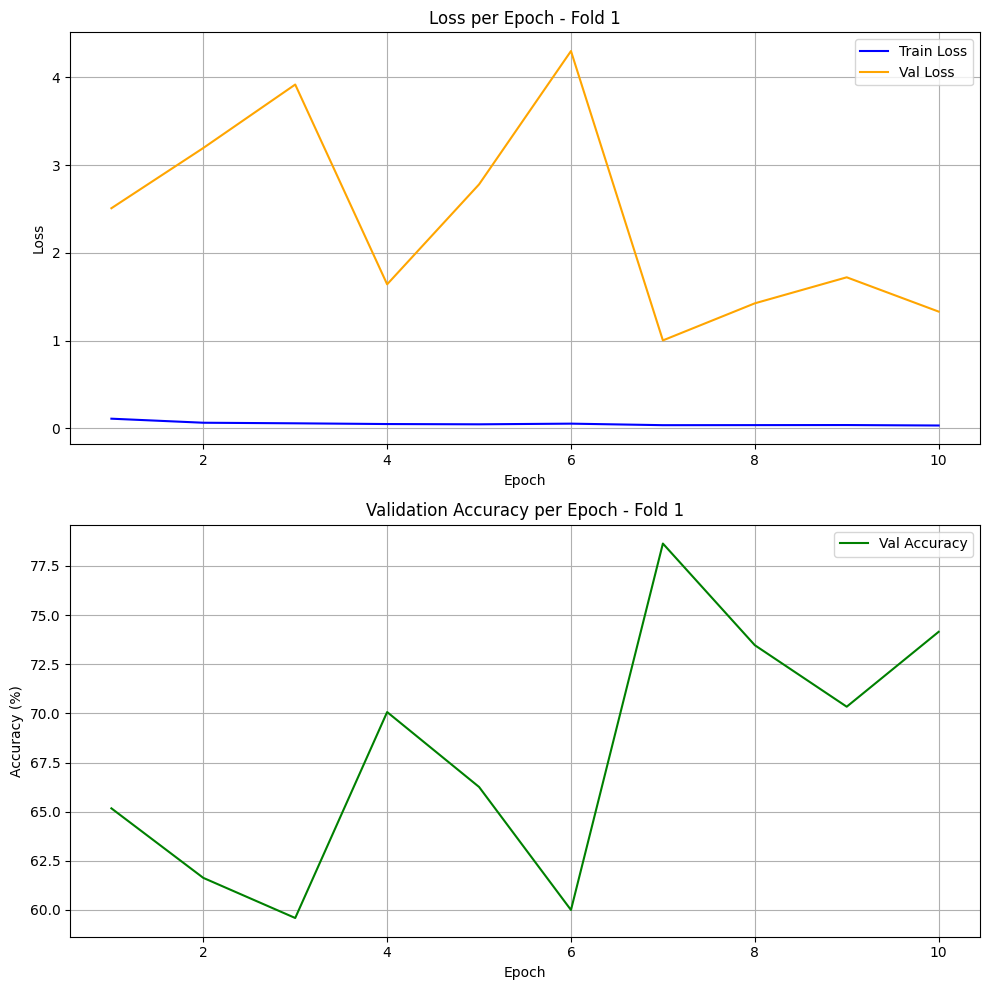


Fold [2/10]
--------------------------------------------------
  Train: 6613장 | Val: 735장
Sequential(
  (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ReLU(inplace=True)
  (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (3): ReLU(inplace=True)
  (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (6): ReLU(inplace=True)
  (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (8): ReLU(inplace=True)
  (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (11): ReLU(inplace=True)
  (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (13): ReLU(inplace=True)
  (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (15): ReLU(inplace=True)
  (16): Conv2d(256, 256, k

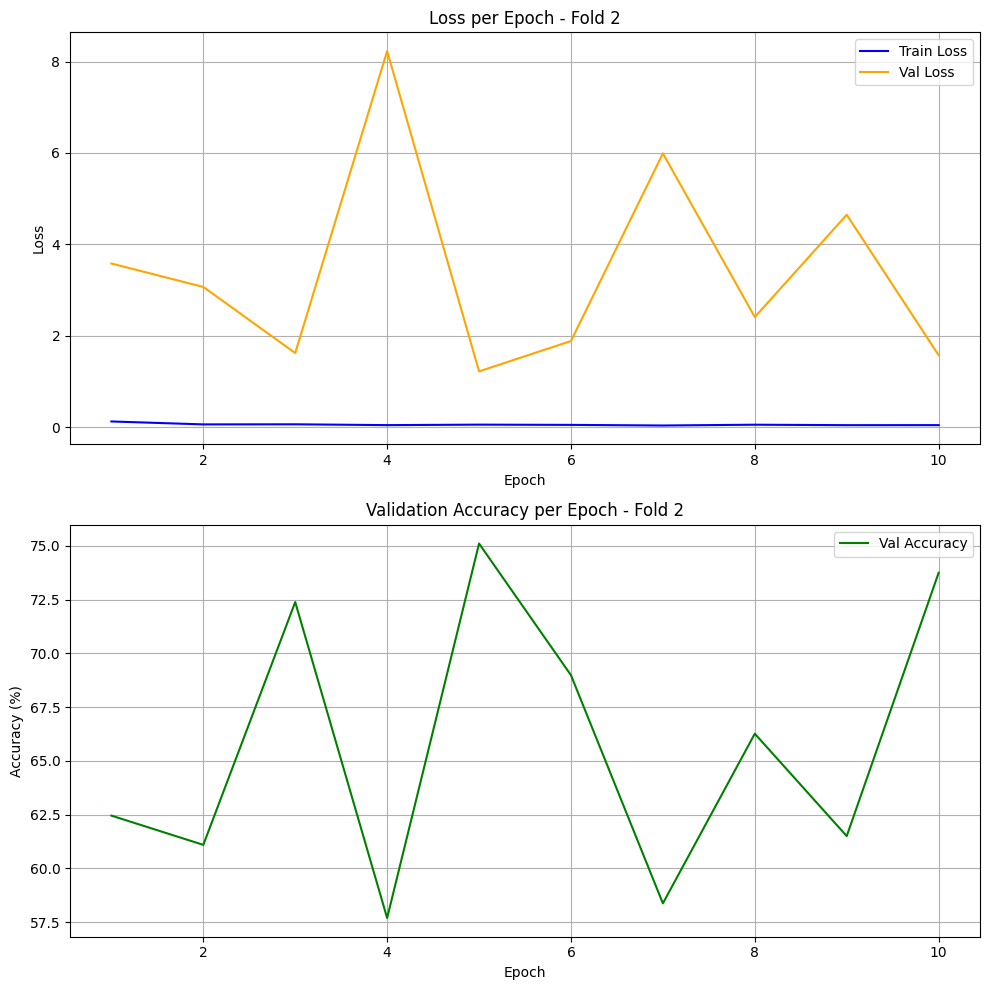


Fold [3/10]
--------------------------------------------------
  Train: 6613장 | Val: 735장
Sequential(
  (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ReLU(inplace=True)
  (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (3): ReLU(inplace=True)
  (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (6): ReLU(inplace=True)
  (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (8): ReLU(inplace=True)
  (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (11): ReLU(inplace=True)
  (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (13): ReLU(inplace=True)
  (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (15): ReLU(inplace=True)
  (16): Conv2d(256, 256, k

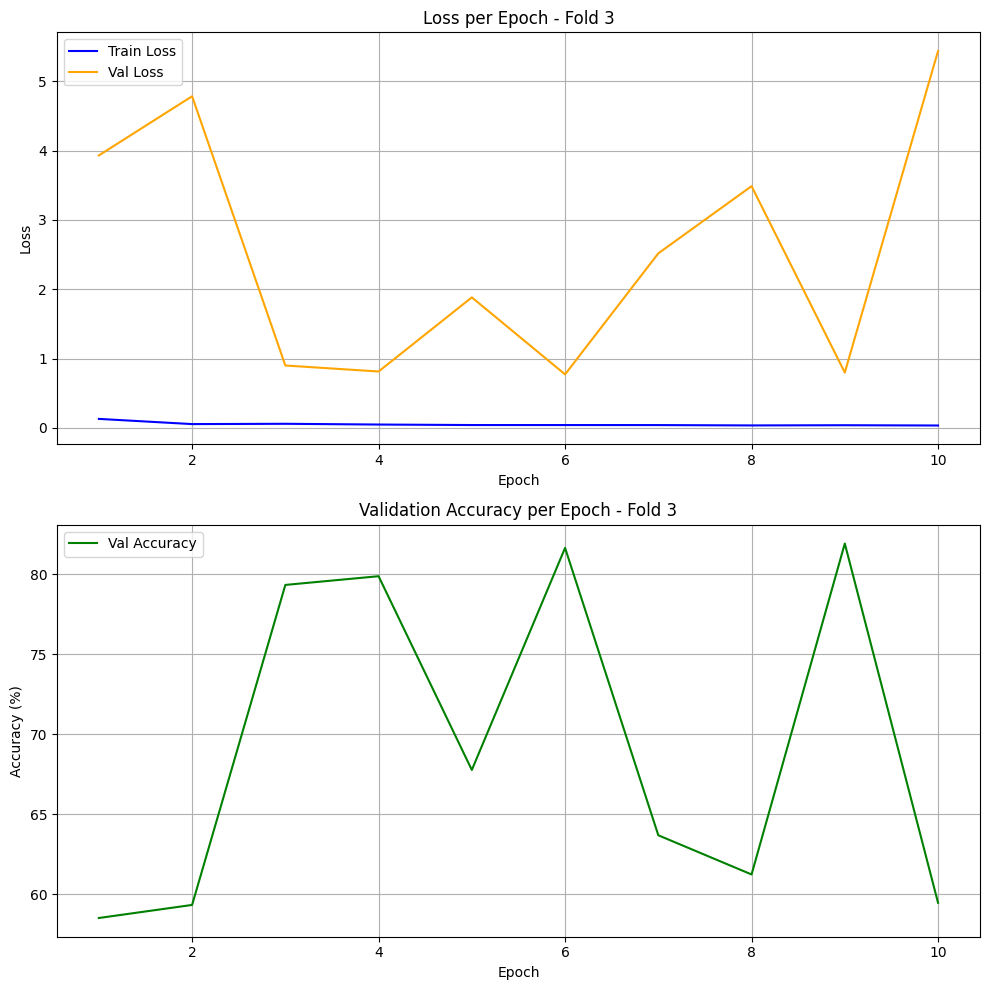


Fold [4/10]
--------------------------------------------------
  Train: 6613장 | Val: 735장
Sequential(
  (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ReLU(inplace=True)
  (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (3): ReLU(inplace=True)
  (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (6): ReLU(inplace=True)
  (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (8): ReLU(inplace=True)
  (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (11): ReLU(inplace=True)
  (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (13): ReLU(inplace=True)
  (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (15): ReLU(inplace=True)
  (16): Conv2d(256, 256, k

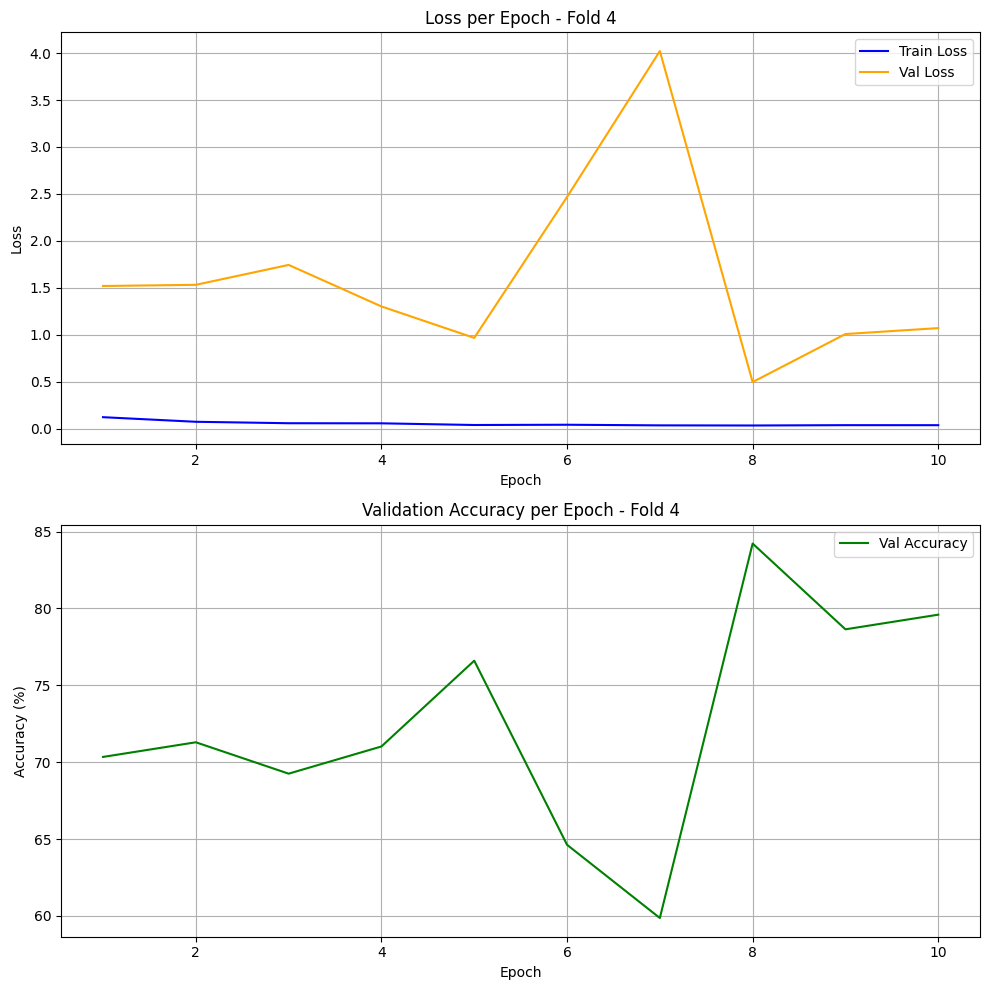


Fold [5/10]
--------------------------------------------------
  Train: 6613장 | Val: 735장
Sequential(
  (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ReLU(inplace=True)
  (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (3): ReLU(inplace=True)
  (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (6): ReLU(inplace=True)
  (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (8): ReLU(inplace=True)
  (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (11): ReLU(inplace=True)
  (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (13): ReLU(inplace=True)
  (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (15): ReLU(inplace=True)
  (16): Conv2d(256, 256, k

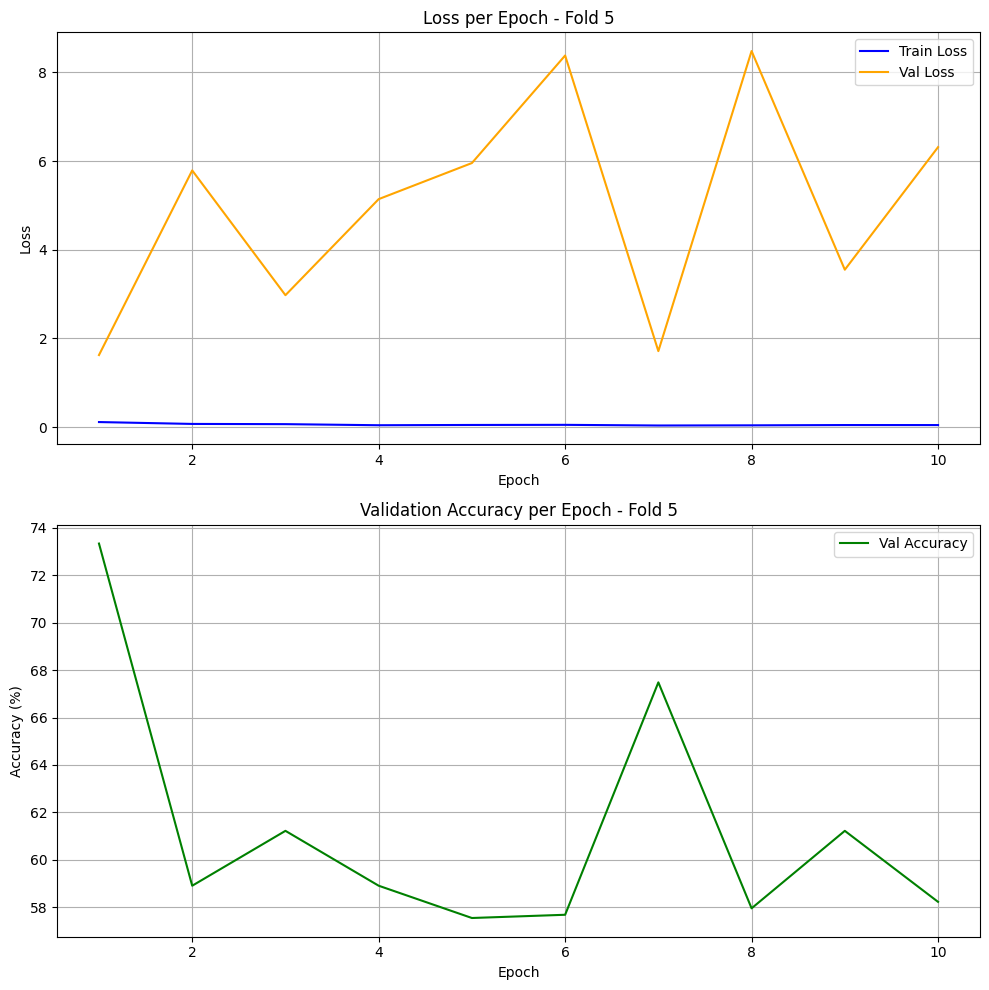


Fold [6/10]
--------------------------------------------------
  Train: 6613장 | Val: 735장
Sequential(
  (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ReLU(inplace=True)
  (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (3): ReLU(inplace=True)
  (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (6): ReLU(inplace=True)
  (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (8): ReLU(inplace=True)
  (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (11): ReLU(inplace=True)
  (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (13): ReLU(inplace=True)
  (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (15): ReLU(inplace=True)
  (16): Conv2d(256, 256, k

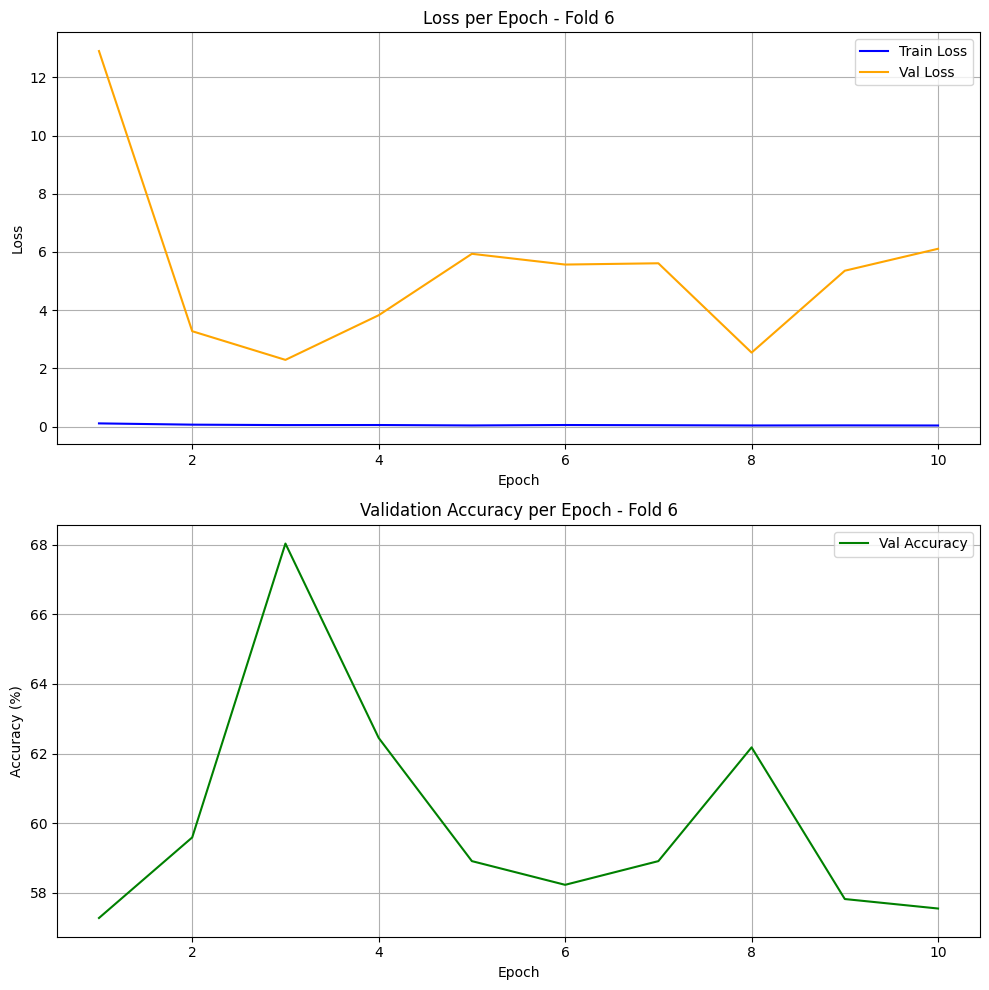


Fold [7/10]
--------------------------------------------------
  Train: 6613장 | Val: 735장
Sequential(
  (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ReLU(inplace=True)
  (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (3): ReLU(inplace=True)
  (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (6): ReLU(inplace=True)
  (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (8): ReLU(inplace=True)
  (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (11): ReLU(inplace=True)
  (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (13): ReLU(inplace=True)
  (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (15): ReLU(inplace=True)
  (16): Conv2d(256, 256, k

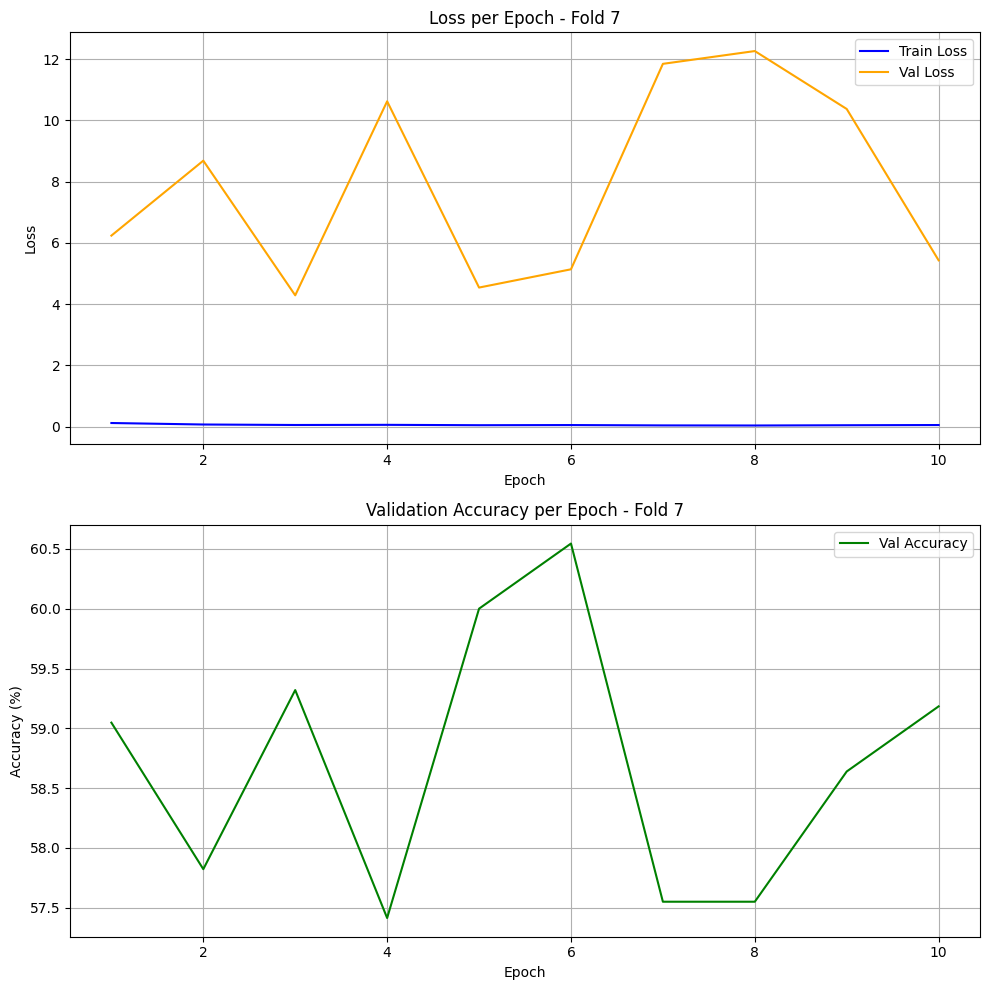


Fold [8/10]
--------------------------------------------------
  Train: 6613장 | Val: 735장
Sequential(
  (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ReLU(inplace=True)
  (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (3): ReLU(inplace=True)
  (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (6): ReLU(inplace=True)
  (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (8): ReLU(inplace=True)
  (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (11): ReLU(inplace=True)
  (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (13): ReLU(inplace=True)
  (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (15): ReLU(inplace=True)
  (16): Conv2d(256, 256, k

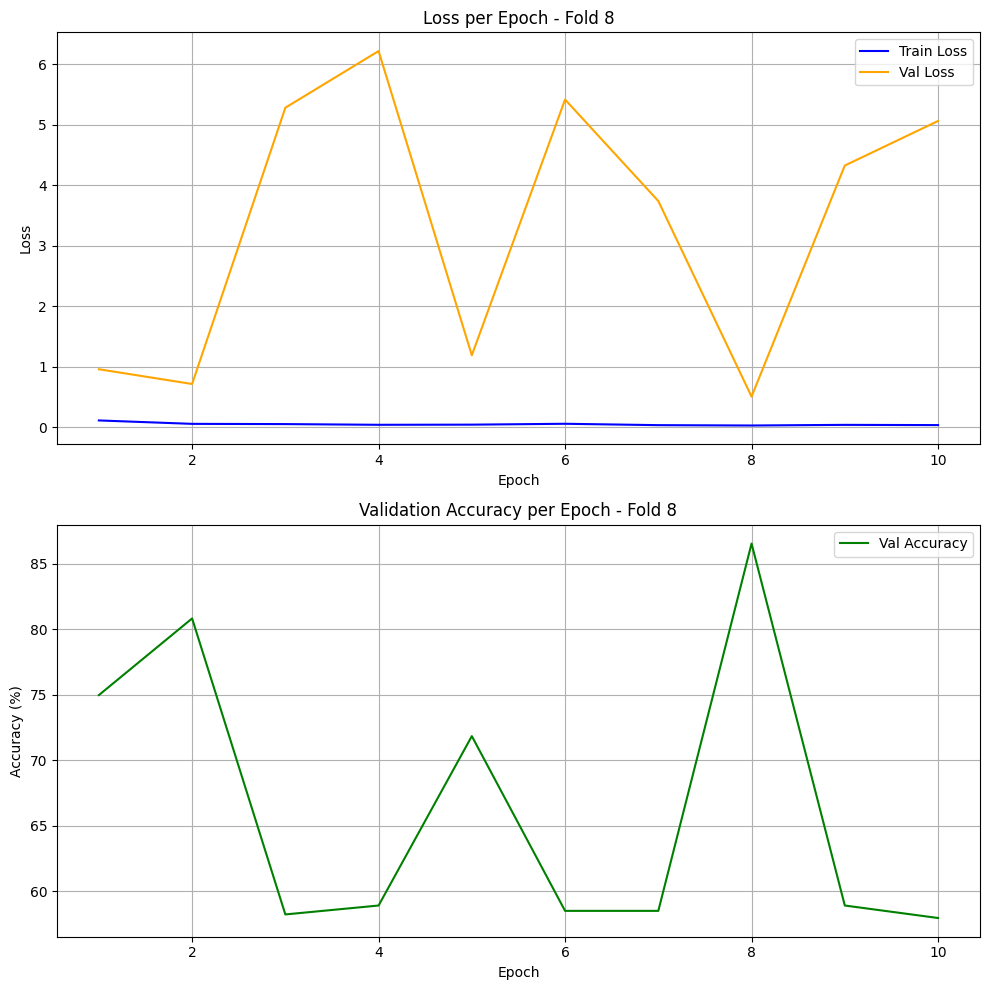


Fold [9/10]
--------------------------------------------------
  Train: 6614장 | Val: 734장
Sequential(
  (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ReLU(inplace=True)
  (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (3): ReLU(inplace=True)
  (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (6): ReLU(inplace=True)
  (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (8): ReLU(inplace=True)
  (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (11): ReLU(inplace=True)
  (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (13): ReLU(inplace=True)
  (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (15): ReLU(inplace=True)
  (16): Conv2d(256, 256, k

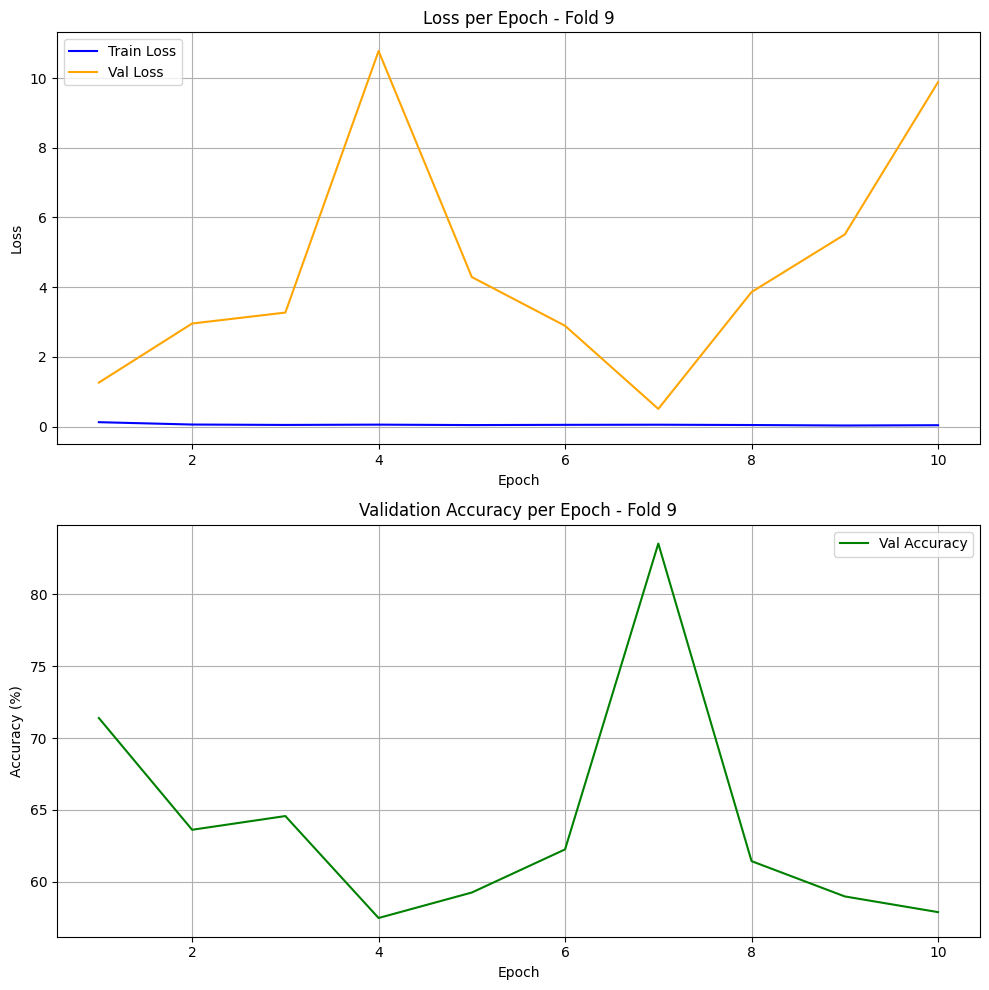


Fold [10/10]
--------------------------------------------------
  Train: 6614장 | Val: 734장
Sequential(
  (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ReLU(inplace=True)
  (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (3): ReLU(inplace=True)
  (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (6): ReLU(inplace=True)
  (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (8): ReLU(inplace=True)
  (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (11): ReLU(inplace=True)
  (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (13): ReLU(inplace=True)
  (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (15): ReLU(inplace=True)
  (16): Conv2d(256, 256, 

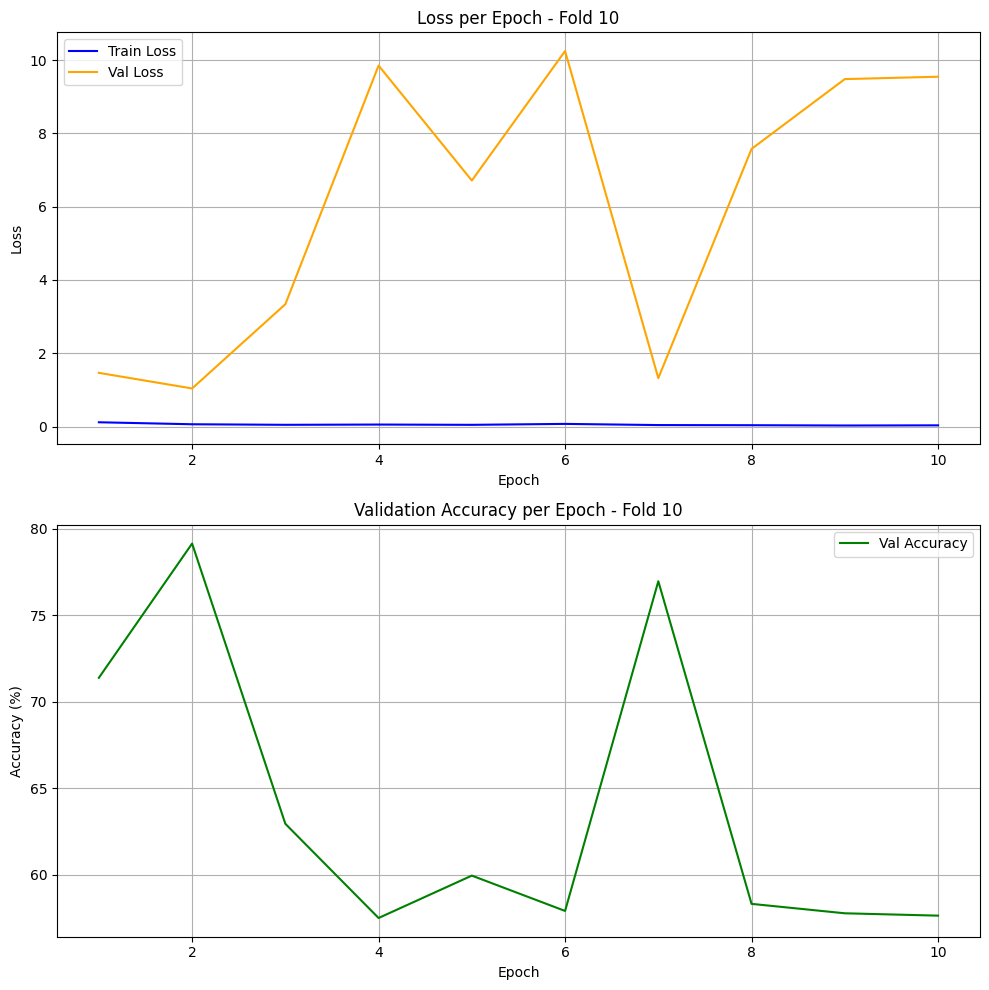

In [12]:
# 10-fold cross validation
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=42)

fold_accs = [] # fold별 최종 accuracy
all_fold_train_losses, all_fold_val_losses = [], [] # fold별 train_loss, val_loss 저장
all_fold_train_accs,   all_fold_val_accs   = [], [] # fold별 train_accuracy, val_accuracy 저장

for fold, (train_idx, val_idx) in enumerate(skf.split(np.zeros(len(all_targets)), all_targets),1) :
    set_seed(42)

    print(f"\nFold [{fold}/{N_SPLITS}]")
    print("-" * 50)

    # 데이터셋 분할
    # Subset : 전체 데이터에서 해당 인덱스만 추출
    train_dataset = Subset(full_dataset_train_tf, train_idx)
    val_dataset   = Subset(full_dataset_val_tf,   val_idx)

    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
    val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)

    print(f"  Train: {len(train_dataset)}장 | Val: {len(val_dataset)}장")

    # fold마다 모델 새로 초기화
    model = MVGG19(num_classes=NUM_CLASSES).to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    # filter → freeze된 backbone 제외하고 학습 가능한 파라미터만 전달
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=LR)

    fold_train_losses, fold_val_losses = [], []
    fold_train_accs,   fold_val_accs   = [], []

    # epoch 루프
    for epoch in range(1, EPOCHS + 1):
        train_loss, train_acc = train(model, train_loader, criterion, optimizer)
        val_loss,   val_acc   = test(model, val_loader, criterion)

        # 매 epoch 결과 기록
        fold_train_losses.append(train_loss)
        fold_val_losses.append(val_loss)
        fold_train_accs.append(train_acc)
        fold_val_accs.append(val_acc)

        print(f"\nEpoch [{epoch:02d}/{EPOCHS}]")
        print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
        print(f"  Val   Loss: {val_loss:.4f} | Val   Acc: {val_acc:.2f}%")
        print("-" * 50)

    # fold 결과 저장
    all_fold_train_losses.append(fold_train_losses)
    all_fold_val_losses.append(fold_val_losses)
    all_fold_train_accs.append(fold_train_accs)
    all_fold_val_accs.append(fold_val_accs)

    # 마지막 epoch의 val accuracy를 fold의 대표값으로 저장(10번째 epoch)
    fold_accs.append(fold_val_accs[-1])

    # fold별 그래프
    epochs_range = range(1, EPOCHS + 1)
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10))

    ax1.plot(epochs_range, fold_train_losses, label="Train Loss", color='blue')
    ax1.plot(epochs_range, fold_val_losses,   label="Val Loss",   color='orange')
    ax1.set_title(f"Loss per Epoch - Fold {fold}")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Loss")
    ax1.legend()
    ax1.grid(True)

    ax2.plot(epochs_range, fold_val_accs, label="Val Accuracy", color='green')
    ax2.set_title(f"Validation Accuracy per Epoch - Fold {fold}")
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("Accuracy (%)")
    ax2.legend()
    ax2.grid(True)

    plt.tight_layout()
    plt.savefig(f"mvgg19_fold{fold}_result.png", dpi=150)
    plt.show()

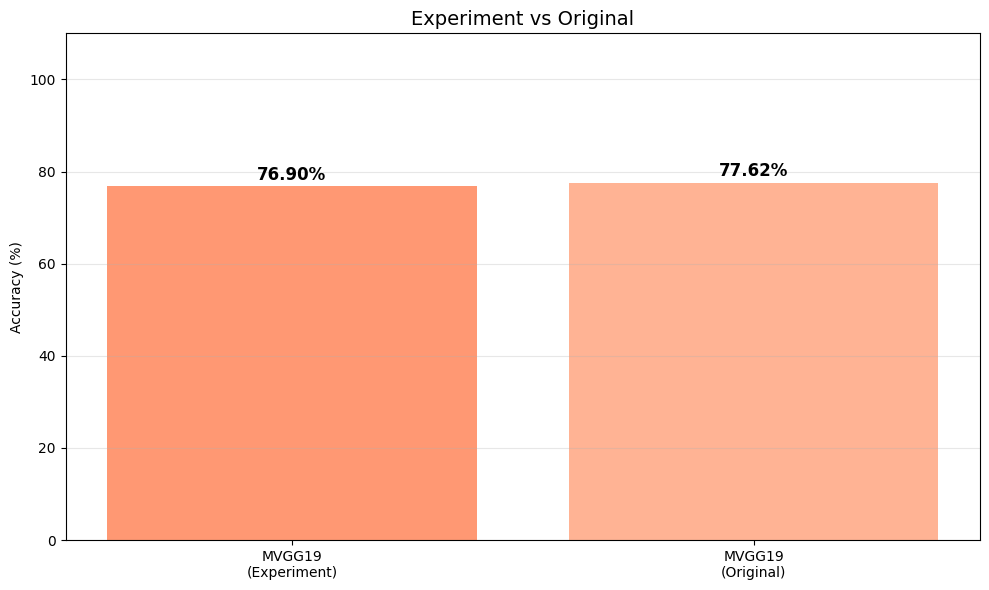

In [3]:
import matplotlib.pyplot as plt

labels = ['MVGG19\n(Experiment)', 'MVGG19\n(Original)']
values = [76.9, 77.62]
colors = ['coral', 'lightsalmon']

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(labels, values, color=colors, alpha=0.8)

# 막대 위에 수치 표시
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.2f}%', ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_title("Experiment vs Original", fontsize=14)
ax.set_ylabel("Accuracy (%)")
ax.set_ylim(0, 110)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig("comparison_result.png", dpi=150)
plt.show()